В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import roc_auc_score, confusion_matrix, mean_squared_error, r2_score

Area under ROC score on Train dataset: 90.19%


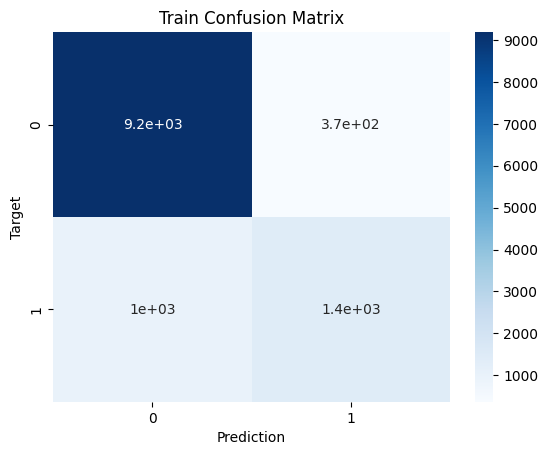

Area under ROC score on Validation dataset: 88.39%


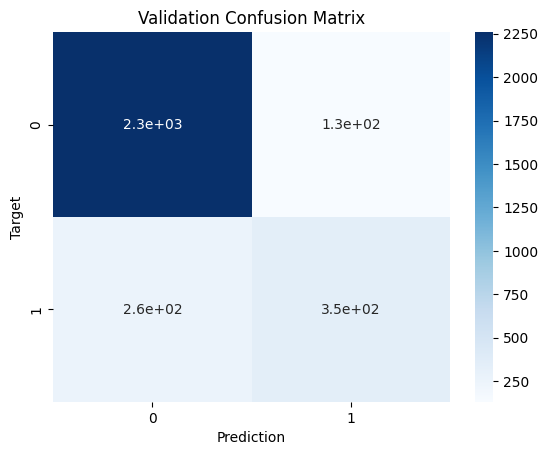

['model_pipeline.joblib']

In [20]:
raw_df = pd.read_csv('data/train.csv', index_col=0)

train_df, val_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify=raw_df['Exited'])

# Створюємо трен. і вал. набори
input_cols = list(train_df.columns)[1:-1]
target_col = 'Exited'
train_inputs, train_targets = train_df[input_cols], train_df[target_col]
val_inputs, val_targets = val_df[input_cols], val_df[target_col]

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()[:-1]
categorical_cols = train_inputs.select_dtypes(include='object').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Створюємо пайплайн, який спочатку запускає препроцесинг, потім тренуємо модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    roc_auc = roc_auc_score(targets, model_pipeline.predict_proba(inputs)[:, 1])
    print(f"Area under ROC score on {name} dataset: {roc_auc*100:.2f}%")
    confusion_matrix_ = confusion_matrix(targets, preds)
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'model_pipeline.joblib')


**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Area under ROC score on Train (poly2) dataset: 94.24%


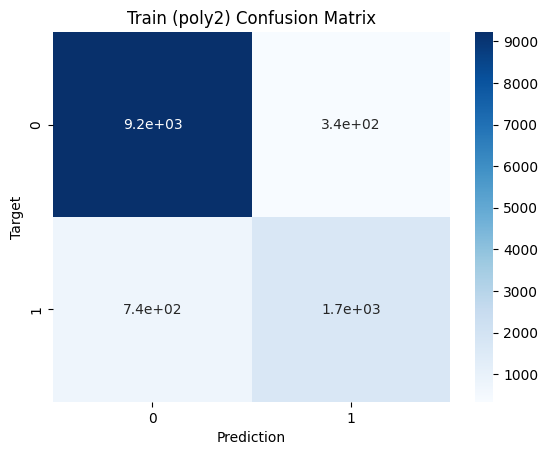

Area under ROC score on Validation (poly2) dataset: 93.07%


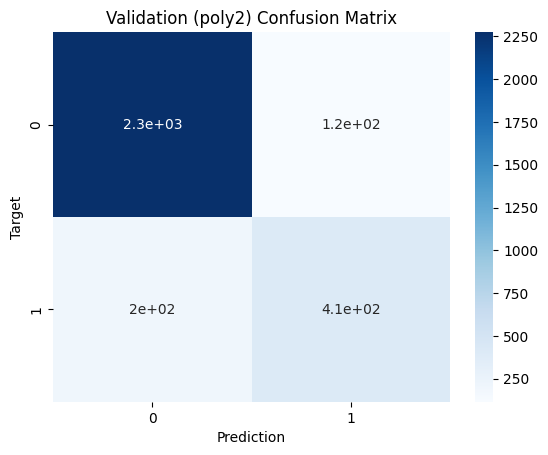

In [3]:
numeric_transformer_poly2 = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

preprocessor_poly2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly2, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

model_pipeline_poly2 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly2),
    ('classifier', LogisticRegression(solver='liblinear'))
])


model_pipeline_poly2.fit(train_inputs, train_targets)

# Метрики
train_preds_poly2 = predict_and_plot(model_pipeline_poly2, train_inputs, train_targets, 'Train (poly2)')
val_preds_poly2 = predict_and_plot(model_pipeline_poly2, val_inputs, val_targets, 'Validation (poly2)')

**Висновки по моделі з поліноміальними ознаками (degree=2):**

Порівняйте отримані ROC-AUC з базовою моделлю (Train: 90.19%, Validation: 88.39%).

- **Overfit** — якщо ROC-AUC на Train значно вищий за Validation (наприклад, >5% різниці). Модель запам'ятовує тренувальні дані.
- **Underfit** — якщо обидві метрики низькі і близькі одна до одної. Модель недостатньо складная.
- **Добра генералізація** — Train і Validation метрики близькі, обидві високі. Модель добре узагальнює на нові дані.

Генералізація: Train і Validation близькі (різниця ~1.17%), обидві метрики високі — модель добре узагальнює.
Overfit: Немає, бо різниця менша за 5%.
Underfit: Немає, бо метрики високі.

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Area under ROC score on Train (poly4) dataset: 94.84%


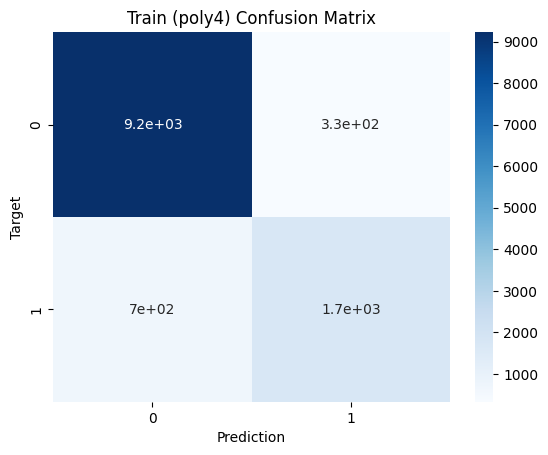

Area under ROC score on Validation (poly4) dataset: 93.57%


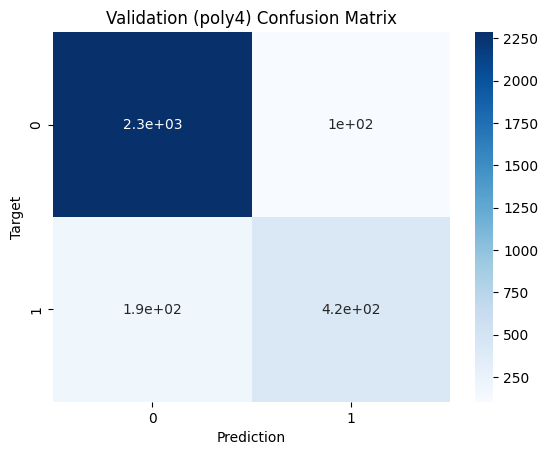

In [4]:
numeric_transformer_poly4 = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=4, include_bias=False)),
    ('scaler', StandardScaler())
])

preprocessor_poly4 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly4, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

model_pipeline_poly4 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly4),
    ('classifier', LogisticRegression(solver='liblinear'))
])

model_pipeline_poly4.fit(train_inputs, train_targets)

train_preds_poly4 = predict_and_plot(model_pipeline_poly4, train_inputs, train_targets, 'Train (poly4)')
val_preds_poly4 = predict_and_plot(model_pipeline_poly4, val_inputs, val_targets, 'Validation (poly4)')

In [5]:
test_raw_df = pd.read_csv('data/test.csv')

In [11]:
submission = pd.read_csv('data/sample_submission.csv')

In [12]:
submission

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5
...,...,...
9995,24995,0.5
9996,24996,0.5
9997,24997,0.5
9998,24998,0.5


In [ ]:
test_raw_df = pd.read_csv('data/test.csv', index_col=0)

test_inputs = test_raw_df[input_cols]
exited_proba = model_pipeline_poly4.predict_proba(test_inputs)[:, 1]

submission = pd.DataFrame({
    'id': test_raw_df.index,
    'Exited': exited_proba
})

submission.to_csv('submission.csv', index=False)

**Висновки по моделі регресії (degree=5):**

- **Overfit** — якщо Train R² значно вищий за Test R² або Test MSE набагато більший за Train MSE.
- **Добра генералізація** — Train і Test метрики близькі.
- Напишіть власний висновок після запуску.

**Висновки по моделі з поліноміальними ознаками (degree=4):**

Порівняйте ROC-AUC з моделлю poly2 (Train: 94.24%, Validation: 93.07%). При degree=4 очікується більше ознак і можливий **overfit** — якщо Train значно вищий за Validation. Напишіть власний висновок після запуску.

Overfit немає — різниця Train–Validation маленька (~1.27%, менше 5%).
Генералізація нормальна — метрики на Train і Validation близькі та високі.
poly4 трохи краща за poly2 — невелике покращення на Train і Validation, різниця між ними не зросла.

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [23]:
new_df = pd.read_csv('regression_data.csv')

feature_cols = ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']
X_reg = new_df[feature_cols]
y_reg = new_df['target']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Як у poly4: окремий numeric_transformer з poly + scaler
numeric_transformer_poly5 = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('scaler', StandardScaler())
])

# Препроцесор (усі колонки числові)
preprocessor_reg = ColumnTransformer(
    transformers=[('num', numeric_transformer_poly5, feature_cols)]
)

# Пайплайн як у poly4
reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_reg),
    ('regressor', LinearRegression())
])

reg_pipeline.fit(X_train_reg, y_train_reg)

y_train_pred = reg_pipeline.predict(X_train_reg)
y_test_pred = reg_pipeline.predict(X_test_reg)

train_mse = mean_squared_error(y_train_reg, y_train_pred)
test_mse = mean_squared_error(y_test_reg, y_test_pred)
train_r2 = r2_score(y_train_reg, y_train_pred)
test_r2 = r2_score(y_test_reg, y_test_pred)

print(f"Train MSE: {train_mse:.4f}, R²: {train_r2:.4f}")
print(f"Test MSE: {test_mse:.4f}, R²: {test_r2:.4f}")

Train MSE: 0.0000, R²: 1.0000
Test MSE: 160.6987, R²: 0.9311


Ці метрики свідчать про переобучення (overfit):
Train MSE ≈ 0, R² = 1 → модель майже точно повторює навчальні дані
Test MSE = 160.7 → на тесті модель помиляється значно більше

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [26]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet

models = {
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'ElasticNet': ElasticNet()
}

results = []
for name, model in models.items():
    numeric_transformer = Pipeline(steps=[
        ('poly', PolynomialFeatures(degree=20, include_bias=False)),
        ('scaler', StandardScaler())
    ])
    preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, feature_cols)])
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    pipeline.fit(X_train_reg, y_train_reg)
    
    train_mse = mean_squared_error(y_train_reg, pipeline.predict(X_train_reg))
    test_mse = mean_squared_error(y_test_reg, pipeline.predict(X_test_reg))
    train_r2 = r2_score(y_train_reg, pipeline.predict(X_train_reg))
    test_r2 = r2_score(y_test_reg, pipeline.predict(X_test_reg))
    
    results.append({'Model': name, 'Train MSE': train_mse, 'Test MSE': test_mse, 'Train R²': train_r2, 'Test R²': test_r2})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

print("\nПорівняння з LinearRegression (degree=5):")
print(f"LinearRegression: Train MSE ≈ 0, Test MSE = 160.7, Test R² = 0.93")

     Model  Train MSE   Test MSE  Train R²  Test R²
     Lasso   2.188532   1.938019  0.998876 0.999169
     Ridge   1.110221 772.706782  0.999430 0.668802
ElasticNet 145.065837 425.349453  0.925524 0.817686

Порівняння з LinearRegression (degree=5):
LinearRegression: Train MSE ≈ 0, Test MSE = 160.7, Test R² = 0.93


**Висновки по Завданню 5:**

Порівняйте Test MSE і Test R² між моделями. Регуляризовані моделі (Lasso, Ridge, ElasticNet) обмежують ваги — це допомагає зменшити overfit при degree=20.

- **Lasso** (L1) — обнуляє частину коефіцієнтів, виконує відбір ознак.
- **Ridge** (L2) — зменшує всі ваги, але не обнуляє.
- **ElasticNet** — комбінує L1 і L2.

Напишіть, яка модель має найменший Test MSE і найкращу генералізацію.

Висновок:
Найкраще узагальнює Lasso.

Найменший Test MSE (1.94) — найменша помилка на тесті.
Test R² = 0.999 — дуже висока якість передбачень.
Немає overfit — Train MSE і Test MSE близькі (2.19 vs 1.94).
Краще за LinearRegression — менша Test MSE і вищий Test R², хоча використовує degree=20 (більше ознак).
Чому Ridge і ElasticNet гірші
Ridge — сильний overfit: Train MSE = 1.1, Test MSE = 772.7. L2-регуляризація зменшує ваги, але не обнуляє їх, тож зайві поліноміальні ознаки все одно впливають.
ElasticNet — проміжний варіант: помірний overfit, Test MSE = 425.